# MCDI500 - Fase 4 (Sumativa): Análisis, reproducibilidad y comunicación de resultados

**Proyecto:** Análisis predictivo de diabetes  
**Integrantes:** Daniel Hormazábal, Cristian Pasten, Enso Guidotti  
**Curso:** MCDI500 — Herramientas de software científico  
**Docente:** Omar Salinas Silva  
**Fecha:** 17-06-2026  
**Repositorio:** https://github.com/DanielParavel/proyecto-grupo4-mcdi500

---

## Descripción

Este notebook constituye el **proyecto final integrador (Fase 4)** del proyecto transversal. Integra las cuatro fases del ABP:

- **F1:** Definición del problema y configuración del entorno reproducible
- **F2:** Obtención, limpieza y transformación del dataset (pipeline funcional)
- **F3:** Núcleo algorítmico POO, recursividad y mediciones de complejidad
- **F4:** Visualizaciones analíticas, storytelling de datos y comunicación de resultados

El notebook corre de principio a fin con **Kernel -> Restart & Run All** sin errores.

---

## Tabla de contenidos

1. [Importación y configuración](#seccion-1)
2. [Carga del dataset RAW (F1-F2)](#seccion-2)
3. [Pipeline POO: preprocesamiento (F2-F3)](#seccion-3)
4. [Validación técnica del pipeline (F3)](#seccion-4)
5. [Análisis exploratorio avanzado (F3)](#seccion-5)
6. [Ranking recursivo de variables (F3)](#seccion-6)
7. [Mediciones de complejidad con timeit (F3)](#seccion-7)
8. [Comparación iterativo vs vectorizado (F3)](#seccion-8)
9. [Storytelling: visualizaciones analíticas (F4)](#seccion-9)
10. [Metodología, trazabilidad y reflexión (F4)](#seccion-10)
11. [Conclusiones (F4)](#seccion-11)
12. [Bibliografía (APA 7)](#seccion-12)


<a id="seccion-1"></a>

---
## 1. Importación y configuración

Stack cientifico del proyecto. Se agrega `seaborn` para las visualizaciones analíticas de F4.


In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timeit
import tracemalloc

# Agregar src/ al path para importar el modulo reutilizable
_nb_dir = os.getcwd()
_src    = os.path.abspath(os.path.join(_nb_dir, '..', 'src'))
if _src not in sys.path:
    sys.path.insert(0, _src)

# Estilo global coherente
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})
plt.rcParams['font.size'] = 11

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")
print("\nLibrerías importadas correctamente ✓")

pandas     : 2.2.2
numpy      : 2.2.6
matplotlib : 3.9.4
seaborn    : 0.13.2

Librerías importadas correctamente ✓


<a id="seccion-2"></a>

---
## 2. Carga del dataset(F1-F2)

Se carga `data/raw/diabetes.csv` (datos crudos del Pima Indians Diabetes Database, versin extendida 15.000 registros). La función valida la presencia del target y reporta el estado inicial antes del preprocesamiento (McKinney, 2022).


In [4]:
def cargar_dataset(ruta):
    """
    Carga el dataset.

    Parámetros
    ----------
    ruta :Ruta al archivo CSV.

    Retorna
    -------
    pd.DataFrame — Dataset listo para análisis.
    """
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró: {ruta}")
    df = pd.read_csv(ruta)
    # Verificaciones básicas de integridad
    assert 'Diabetic' in df.columns, "ERROR: falta la variable objetivo Diabetic"
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas ✓")
    print(f"Columnas  : {df.columns.tolist()}")
    print(f"Nulos     : {df.isnull().sum().sum()}")
    print(f"Diabetic  : {df['Diabetic'].value_counts().to_dict()}")
    return df

df_raw = cargar_dataset('../../data/raw/diabetes.csv')

FEATURES = ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']
TARGET   = 'Diabetic'
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")


Dataset cargado: 15,000 filas × 10 columnas ✓
Columnas  : ['PatientID', 'Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age', 'Diabetic']
Nulos     : 0
Diabetic  : {0: 10000, 1: 5000}

Features (8): ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']


<a id="seccion-3"></a>

---
## 3. Pipeline POO: preprocesamiento (F2-F3)

Las clases del pipeline se importan desde `src/analizador.py`. El pipeline opera sobre los datos crudos demostrando transformaciones efectivas: exclusion de `PatientID`, deduplicacion, imputacion de nulos y normalizacion Min-Max (UNAB, 2026b).

### Arquitectura

```
src/analizador.py
    Transformador (ABC)          <- contrato comun
    +-- ExcluirColumna           <- herencia
    +-- EliminarDuplicados       <- herencia
    +-- ImputarMediana           <- herencia
    +-- NormalizarMinMax         <- herencia
    Pipeline                     <- composicion + polimorfismo
    AnalizadorDiabetes           <- encapsulamiento + cache
```


In [5]:
#  IMPORTAR MÓDULO REUTILIZABLE DESDE src/ Analizador.py
# Asegurar que src/ esté en sys.path (robusto para distintas carpetas de ejecución)
for rel in (os.path.join('..', '..', 'src'), os.path.join('..', 'src'), 'src'):
    ruta_src = os.path.abspath(os.path.join(os.getcwd(), rel))
    if os.path.isdir(ruta_src) and ruta_src not in sys.path:
        sys.path.insert(0, ruta_src)

# Importar módulo reutilizable con clases de transformación y análisis
    from Analizador import (
        Transformador,
        ExcluirColumna,
        EliminarDuplicados,
        ImputarMediana,
        NormalizarMinMax,
        Pipeline,
        AnalizadorDiabetes,
    )

print("Módulo src/Analizador.py importado correctamente ✓")
print()
print("Clases disponibles:")
for cls in [Transformador, ExcluirColumna, EliminarDuplicados,
            ImputarMediana, NormalizarMinMax, Pipeline, AnalizadorDiabetes]:
    print(f"  ✓ {cls.__name__}")


Módulo src/Analizador.py importado correctamente ✓

Clases disponibles:
  ✓ Transformador
  ✓ ExcluirColumna
  ✓ EliminarDuplicados
  ✓ ImputarMediana
  ✓ NormalizarMinMax
  ✓ Pipeline
  ✓ AnalizadorDiabetes


In [6]:
# EJECUCIÓN DEL PIPELINE SOBRE DATOS CRUDOS 
pipeline = Pipeline([
    ExcluirColumna('PatientID'),   # elimina identificador sin valor predictivo
    EliminarDuplicados(),          # garantiza integridad: un registro por paciente
    ImputarMediana(),              # imputa NaN con mediana (robusta a outliers)
    NormalizarMinMax(),            # escala features a [0, 1]
])

print("Etapas del pipeline:")
pipeline.listar_etapas()
print()

# Ejecutar sobre el dataset CRUDO — transformaciones efectivas
df_pipeline = pipeline.ejecutar(df_raw.copy())

# El dataset resultante equivale al diabetes_clean.csv de F2
df = df_pipeline.copy()
print(f"\nDataset procesado listo para análisis:")
print(f"  Filas     : {df.shape[0]:,}")
print(f"  Columnas  : {df.shape[1]}")
print(f"  Nulos     : {df.isnull().sum().sum()}")
print(f"  Rango     : [{df[FEATURES].min().min():.4f}, {df[FEATURES].max().max():.4f}]")

Etapas del pipeline:
  1. ExcluirColumna()
  2. EliminarDuplicados()
  3. ImputarMediana()
  4. NormalizarMinMax()

Pipeline iniciado — 4 etapas

Etapa 1/4: ExcluirColumna()
  [ExcluirColumna] 'PatientID' excluida ✓
Etapa 2/4: EliminarDuplicados()
  [EliminarDuplicados] 0 duplicados eliminados ✓
Etapa 3/4: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 4/4: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  15,000 × 9

Dataset procesado listo para análisis:
  Filas     : 15,000
  Columnas  : 9
  Nulos     : 0
  Rango     : [0.0000, 1.0000]


<a id="seccion-4"></a>

---
## 4. Validación técnica del pipeline

Se verifican tres escenarios según las buenas prácticas de testing (Ramalho, 2022):

- **Caso normal**: dataset estándar, el pipeline ejecuta sin errores.
- **Caso límite**: columna a excluir no existe, una sola fila, columna constante.
- **Excepción**: etapa inválida en el pipeline lanza `TypeError` controlado.


In [7]:
# CASO NORMAL
print("TEST 1 — Caso normal\n")
df_test = df.copy()
pipe_test = Pipeline([ImputarMediana(), NormalizarMinMax()])
df_resultado = pipe_test.ejecutar(df_test)

# Verificaciones básicas
assert df_resultado.isnull().sum().sum() == 0, "ERROR: hay nulos"
assert df_resultado.shape[0] == len(df), "ERROR: se perdieron filas"
assert set(df_resultado['Diabetic'].unique()) == {0, 1}, "ERROR: target inválido"
print(f"\n✓ Caso normal: {df_resultado.shape}, 0 nulos, target válido")

# CASO LÍMITE 1: columna a excluir no existe 
print("\nTEST 2 — Caso límite: columna inexistente\n")
pipe_limite = Pipeline([ExcluirColumna('ColumnaQueNoExiste')])
df_limite = pipe_limite.ejecutar(df.copy())
assert df_limite.shape == df.shape, "ERROR: el shape cambió"
print(f"✓ Columna inexistente manejada sin error: shape {df_limite.shape}")

# CASO LÍMITE 2: dataset de una sola fila 
print("\nTEST 3 — Caso límite: dataset de 1 fila\n")

df_una_fila = df.iloc[:1].copy()
pipe_una = Pipeline([ImputarMediana(), NormalizarMinMax()])
df_una_resultado = pipe_una.ejecutar(df_una_fila)
assert len(df_una_resultado) == 1
print(f"✓ Dataset de 1 fila procesado correctamente: {df_una_resultado.shape}")

# CASO LÍMITE 3: columna constante (rango = 0) 
print("\nTEST 4 — Caso límite: columna constante\n")
df_constante = df.copy()
df_constante['BMI'] = 0.5  # columna constante → rango = 0
pipe_const = Pipeline([NormalizarMinMax()])
df_const_resultado = pipe_const.ejecutar(df_constante)
# La columna constante no debe generar NaN (división por cero protegida)
assert df_const_resultado['BMI'].isnull().sum() == 0
print(f"✓ Columna constante procesada sin NaN: BMI={df_const_resultado['BMI'].unique()}")

# EXCEPCIÓN: etapa inválida 
print("\nTEST 5 — Excepción: etapa no es Transformador\n")
try:
    pipe_invalido = Pipeline(["esto no es un transformador"])
except TypeError as e:
    print(f"✓ TypeError capturado correctamente: {e}")

print("\n Todos los tests pasados")


TEST 1 — Caso normal

Pipeline iniciado — 2 etapas

Etapa 1/2: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 2/2: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  15,000 × 9

✓ Caso normal: (15000, 9), 0 nulos, target válido

TEST 2 — Caso límite: columna inexistente

Pipeline iniciado — 1 etapas

Etapa 1/1: ExcluirColumna()
  [ExcluirColumna] 'ColumnaQueNoExiste' no encontrada — omitida

Pipeline completado ✓  →  15,000 × 9
✓ Columna inexistente manejada sin error: shape (15000, 9)

TEST 3 — Caso límite: dataset de 1 fila

Pipeline iniciado — 2 etapas

Etapa 1/2: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 2/2: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  1 × 9
✓ Dataset de 1 fila procesado correctamente: (1, 9)

TEST 4 — Caso límite: columna constante

Pipeline iniciado — 1 etapas

Etapa 1/1: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas 

<a id="seccion-5"></a>

---
## 5. Análisis exploratorio avanzado (F3)

La clase `AnalizadorDiabetes` encapsula el análisis con caché interno. Los resultados de esta sección alimentan directamente las visualizaciones de F4.

In [8]:
analizador = AnalizadorDiabetes(df, FEATURES, TARGET)

# Estadisticos por clase
stats = analizador.calcular_estadisticos_por_clase()
cols  = ['Media (No diabético)', 'Media (Diabético)', 'Δ Media (1-0)']
print("Estadísticos por clase (ordenado por poder discriminativo):\n")
print(stats[cols].sort_values('Δ Media (1-0)', ascending=False).to_string())
mejor = stats['Δ Media (1-0)'].idxmax()
print(f"\nVariable más discriminativa: {mejor} (Δ={stats.loc[mejor, 'Δ Media (1-0)']:.4f})")


AnalizadorDiabetes inicializado ✓
  Filas    : 15,000
  Features : 8
  Target   : 'Diabetic'
Estadísticos por clase (ordenado por poder discriminativo):

                        Media (No diabético)  Media (Diabético)  Δ Media (1-0)
Feature                                                                       
Pregnancies                           0.1606             0.3698         0.2092
Age                                   0.1109             0.2678         0.1569
BMI                                   0.3134             0.4286         0.1152
SerumInsulin                          0.1281             0.2171         0.0890
DiabetesPedigree                      0.1239             0.1853         0.0614
PlasmaGlucose                         0.4119             0.4706         0.0587
TricepsThickness                      0.2354             0.2902         0.0548
DiastolicBloodPressure                0.4961             0.5310         0.0349

Variable más discriminativa: Pregnancies (Δ=0.2092)


In [9]:
# Detección de outliers
outliers = analizador.detectar_outliers_iqr()
print("Detección de outliers (IQR):\n")
print(outliers[['N Outliers', '% Outliers', 'Lím. Inf', 'Lím. Sup']] 
      .sort_values('N Outliers', ascending=False).to_string())
print(f"\nVariable con más outliers: {outliers['N Outliers'].idxmax()} "
      f"({outliers['N Outliers'].max()} — {outliers['% Outliers'].max():.2f}%)")


Detección de outliers (IQR):

                        N Outliers  % Outliers  Lím. Inf  Lím. Sup
Feature                                                           
Age                           1019        6.79   -0.3304    0.5982
SerumInsulin                   666        4.44   -0.2662    0.5287
DiabetesPedigree               475        3.17   -0.2960    0.5649
TricepsThickness                31        0.21   -0.3605    0.8488
DiastolicBloodPressure           0        0.00   -0.0699    1.0914
PlasmaGlucose                    0        0.00   -0.1858    1.0304
Pregnancies                      0        0.00   -0.6429    1.0714
BMI                              0        0.00   -0.6328    1.2703

Variable con más outliers: Age (1019 — 6.79%)


In [10]:
# Correlaciones y distribuciones
matriz_corr = analizador.calcular_correlaciones()
corr_target = matriz_corr[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlación con Diabetic:\n")
print(corr_target.to_string())


Correlación con Diabetic:

Pregnancies               0.4073
Age                       0.3426
SerumInsulin              0.2474
BMI                       0.2105
DiabetesPedigree          0.1703
TricepsThickness          0.1525
PlasmaGlucose             0.1280
DiastolicBloodPressure    0.0913


<a id="seccion-6"></a>

---
## 6. Ranking recursivo: merge sort

Se implementa un **merge sort recursivo** para ordenar las features por correlación absoluta con la variable objetivo. Complejidad: **O(p·log p)**.

- **Caso base**: lista de 0 o 1 elementos, ya está ordenada.
- **Caso recursivo**: dividir en dos mitades, ordenar cada una y combinar.

Esta elección se justifica algorítmicamente: un ordenamiento iterativo ingenuo es O(p²). Con 8 features la diferencia no es dramática, pero escalaría mejor con datasets de alta dimensionalidad (UNAB, 2026a).

In [11]:
ranking = analizador.rankear_variables_recursivo()
print("Ranking (merge sort recursivo):\n")
print(ranking.to_string())


Ranking (merge sort recursivo):

                     Feature  Correlación  |Correlación|
Rank                                                    
1                Pregnancies       0.4073         0.4073
2                        Age       0.3426         0.3426
3               SerumInsulin       0.2474         0.2474
4                        BMI       0.2105         0.2105
5           DiabetesPedigree       0.1703         0.1703
6           TricepsThickness       0.1525         0.1525
7              PlasmaGlucose       0.1280         0.1280
8     DiastolicBloodPressure       0.0913         0.0913


<a id="seccion-7"></a>

---
## 7. Mediciones de complejidad con timeit (F3)

Se mide el tiempo de cada metodo sobre 5 tamaños de dataset (1k a 15k filas), verificando empiricamente las complejidades teóricas.


In [24]:
import io, contextlib

def medir_con_timeit(df, features, target, tamanos=None, n_rep=3):
    if tamanos is None:
        tamanos = [1000, 3000, 6000, 10000, 15000]
    registros = []
    sink = io.StringIO()                              # absorbe prints de __init__
    for n in tamanos:
        df_sub  = df.iloc[:n].copy()
        with contextlib.redirect_stdout(sink):
            t_stats = timeit.timeit(lambda: AnalizadorDiabetes(df_sub, features, target).calcular_estadisticos_por_clase(), number=n_rep) / n_rep
            t_iqr   = timeit.timeit(lambda: AnalizadorDiabetes(df_sub, features, target).detectar_outliers_iqr(), number=n_rep) / n_rep
            t_corr  = timeit.timeit(lambda: AnalizadorDiabetes(df_sub, features, target).calcular_correlaciones(), number=n_rep) / n_rep
            az_temp = AnalizadorDiabetes(df_sub, features, target)
            az_temp.calcular_correlaciones()
            t_rank  = timeit.timeit(lambda: az_temp.rankear_variables_recursivo(), number=n_rep) / n_rep
        registros.append({'N': n,
            'Stats O(n·p) ms':   round(t_stats * 1000, 2),
            'IQR O(n·p) ms':     round(t_iqr   * 1000, 2),
            'Corr O(n·p²) ms':   round(t_corr  * 1000, 2),
            'Rank O(p·log p) ms': round(t_rank  * 1000, 3),
        })
        print(f"  n={n:<6} stats={t_stats*1000:.1f} ms  iqr={t_iqr*1000:.1f} ms  corr={t_corr*1000:.1f} ms  rank={t_rank*1000:.3f} ms")
    return pd.DataFrame(registros).set_index('N')

print("Midiendo complejidad temporal (timeit, n_rep=3)...\n")
df_tiempos = medir_con_timeit(df, FEATURES, TARGET)
print("\nTabla de tiempos (ms):")
print(df_tiempos.to_string())


Midiendo complejidad temporal (timeit, n_rep=3)...

  n=1000   stats=7.1 ms  iqr=6.5 ms  corr=0.5 ms  rank=0.397 ms
  n=3000   stats=6.4 ms  iqr=6.7 ms  corr=1.3 ms  rank=0.390 ms
  n=6000   stats=6.8 ms  iqr=7.3 ms  corr=1.5 ms  rank=0.388 ms
  n=10000  stats=7.5 ms  iqr=8.1 ms  corr=2.7 ms  rank=0.388 ms
  n=15000  stats=9.1 ms  iqr=9.4 ms  corr=3.3 ms  rank=0.478 ms

Tabla de tiempos (ms):
       Stats O(n·p) ms  IQR O(n·p) ms  Corr O(n·p²) ms  Rank O(p·log p) ms
N                                                                         
1000              7.14           6.52             0.51               0.397
3000              6.40           6.67             1.26               0.390
6000              6.77           7.30             1.55               0.388
10000             7.49           8.12             2.72               0.388
15000             9.06           9.41             3.28               0.478


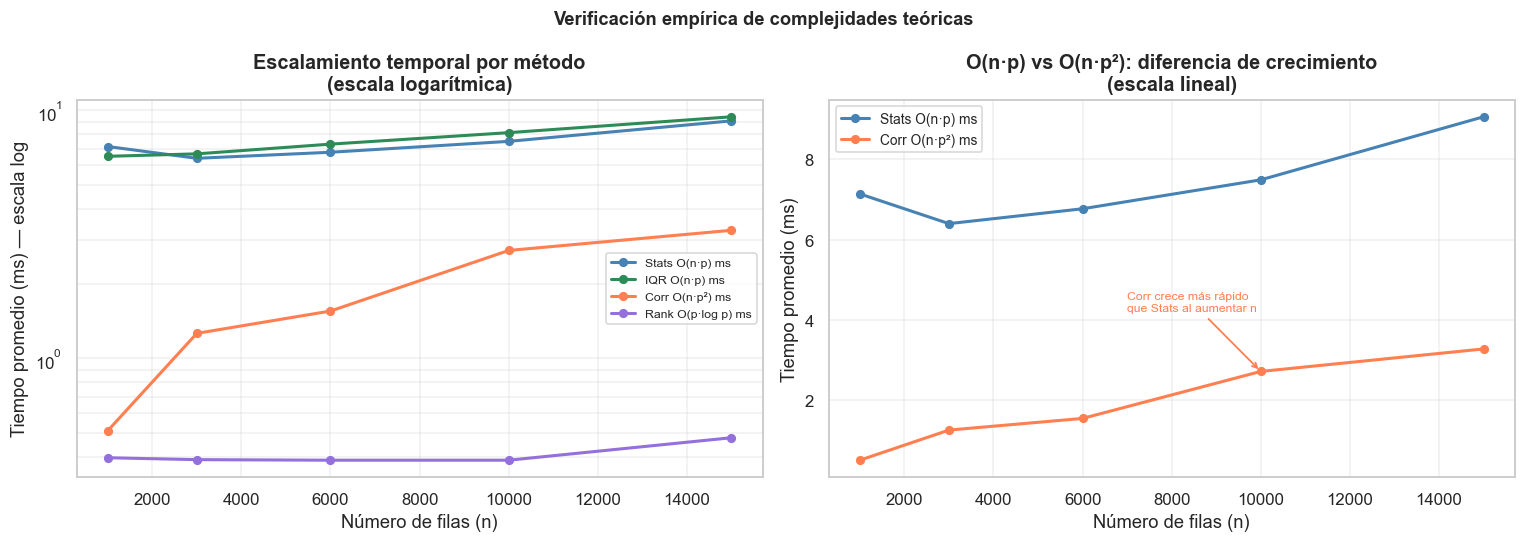

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_map = {
    'Stats O(n·p) ms':    'steelblue',
    'IQR O(n·p) ms':      'seagreen',
    'Corr O(n·p²) ms':    'coral',
    'Rank O(p·log p) ms': 'mediumpurple',
}

# Subplot izquierdo – escala log en Y para que todas las series sean visibles
for col, color in colores_map.items():
    axes[0].plot(df_tiempos.index, df_tiempos[col], 'o-', label=col, color=color, linewidth=2, markersize=5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Número de filas (n)')
axes[0].set_ylabel('Tiempo promedio (ms) — escala log')
axes[0].set_title('Escalamiento temporal por método\n(escala logarítmica)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, which='both')

# Subplot derecho – solo O(n·p) vs O(n·p²) en escala lineal para ver diferencia de crecimiento
for col in ['Stats O(n·p) ms', 'Corr O(n·p²) ms']:
    axes[1].plot(df_tiempos.index, df_tiempos[col], 'o-', label=col, color=colores_map[col], linewidth=2, markersize=5)
axes[1].set_xlabel('Número de filas (n)')
axes[1].set_ylabel('Tiempo promedio (ms)')
axes[1].set_title('O(n·p) vs O(n·p²): diferencia de crecimiento\n(escala lineal)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].annotate(
    'Corr crece más rápido\nque Stats al aumentar n',
    xy=(10000, df_tiempos.loc[10000, 'Corr O(n·p²) ms']),
    xytext=(7000, df_tiempos.loc[10000, 'Corr O(n·p²) ms'] + 1.5),
    fontsize=8, color='coral',
    arrowprops=dict(arrowstyle='->', color='coral', lw=1.2)
)

plt.suptitle('Verificación empírica de complejidades teóricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="seccion-8"></a>

---
## 8. Comparación de implementaciones: iterativo vs vectorizado

Se comparan dos implementaciones del mismo cálculo estadístico para demostrar la diferencia de eficiencia entre un enfoque iterativo (bucle fila por fila) y uno vectorizado (operaciones sobre arrays). Esta comparación evidencia el impacto de las decisiones de implementación en la eficiencia computacional (VanderPlas, 2023).

Iterativo   (Python puro) : 1.72 ms
Vectorizado (pandas/NumPy): 0.0387 ms
Speedup                   : 44x más rápido (vectorizado)
Resultados equivalentes   : diferencia = 8.88e-16 ✓


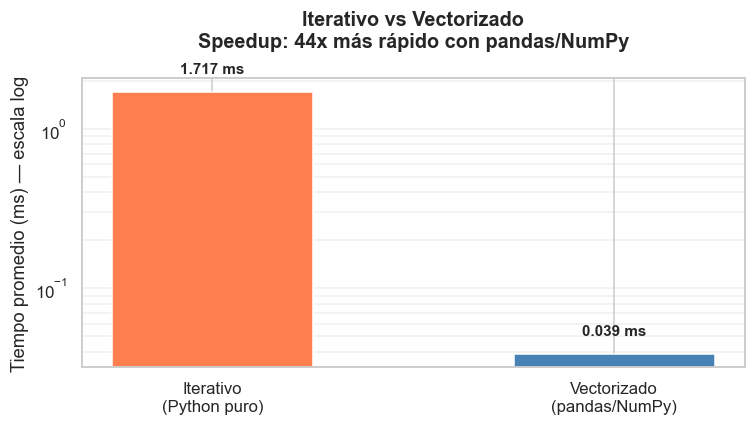

In [30]:
# IMPLEMENTACIÓN A: bucle iterativo (fila por fila)
def calcular_media_iterativo(df, col):
    total = 0.0
    n = 0
    for valor in df[col]:
        total += valor
        n += 1
    return total / n if n > 0 else 0.0

def calcular_media_vectorizado(df, col):
    return df[col].mean()

col_test = 'PlasmaGlucose'
n_reps   = 50

t_iter = timeit.timeit(lambda: calcular_media_iterativo(df, col_test),  number=n_reps) / n_reps
t_vect = timeit.timeit(lambda: calcular_media_vectorizado(df, col_test), number=n_reps) / n_reps

r_iter = calcular_media_iterativo(df, col_test)
r_vect = calcular_media_vectorizado(df, col_test)
assert abs(r_iter - r_vect) < 1e-10, "ERROR: resultados distintos"

speedup = t_iter / t_vect
print(f"Iterativo   (Python puro) : {t_iter*1000:.2f} ms")
print(f"Vectorizado (pandas/NumPy): {t_vect*1000:.4f} ms")
print(f"Speedup                   : {speedup:.0f}x más rápido (vectorizado)")
print(f"Resultados equivalentes   : diferencia = {abs(r_iter - r_vect):.2e} ✓")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [f'Iterativo\n(Python puro)', f'Vectorizado\n(pandas/NumPy)'],
    [t_iter * 1000, t_vect * 1000],
    color=['coral', 'steelblue'], width=0.5, edgecolor='white'
)
ax.set_yscale('log')
ax.set_ylabel('Tiempo promedio (ms) — escala log')
ax.set_title(f'Iterativo vs Vectorizado\nSpeedup: {speedup:.0f}x más rápido con pandas/NumPy\n')
for bar, v in zip(bars, [t_iter * 1000, t_vect * 1000]):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.3, f'{v:.3f} ms',
            ha='center', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='y', which='both')
plt.tight_layout()
plt.show()


<a id="seccion-9"></a>

---
## 9. Storytelling: visualizaciones analiticas (F4)

Los tres graficos muestran una historia progresiva sobre los factores asociados a la diabetes tipo 2 en el dataset:

- **Contexto:** Distribucion de la variable objetivo. Cuantos pacientes son diabeticos y cuantos no?
- **Conflicto:** Las mujeres con mas embarazos tienen mayor prevalencia de diabetes. Pregnancies es la variable mas discriminativa.
- **Resolucion:** El mapa de correlaciones revela que Pregnancies, Age y PlasmaGlucose son las variables mas relacionadas con el diagnostico.


### Contexto: distribución de la variable objetivo
¿Cómo se distribuyen los diagnósticos en el dataset?


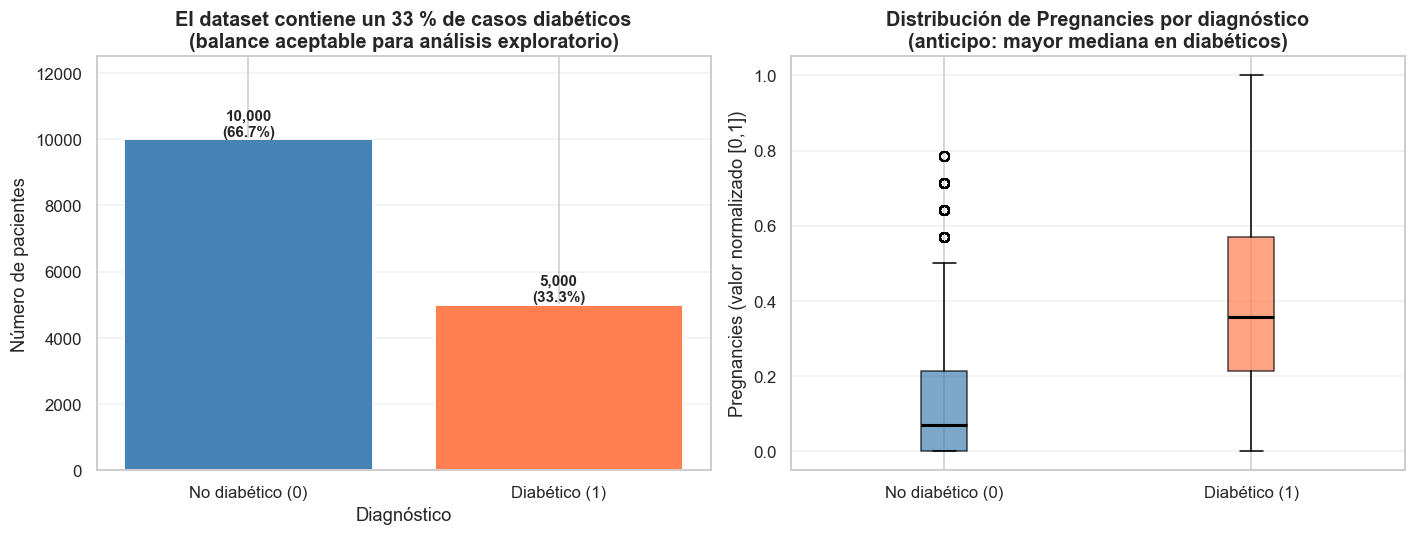


Se muestra: dataset con 15.000 registros y balance 67/33 entre clases.
Se infiere: el desbalance no es severo; no se requiere sobremuestreo para EDA.
Anticipo:   la distribución de Pregnancies ya sugiere mayor exposición en diabéticos (ver boxplot).


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot izquierdo – conteos absolutos con porcentaje
conteos = df[TARGET].value_counts().sort_index()
etiquetas = ['No diabético (0)', 'Diabético (1)']
colores   = ['steelblue', 'coral']

axes[0].bar(etiquetas, conteos.values, color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title('El dataset contiene un 33 % de casos diabéticos\n(balance aceptable para análisis exploratorio)')
axes[0].set_ylabel('Número de pacientes')
axes[0].set_xlabel('Diagnóstico')
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, conteos.max() * 1.25)

# Subplot derecho – boxplot de Pregnancies por clase (añade información nueva)
data_no  = df[df[TARGET] == 0]['Pregnancies']
data_yes = df[df[TARGET] == 1]['Pregnancies']
bp = axes[1].boxplot([data_no, data_yes], patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('coral');     bp['boxes'][1].set_alpha(0.7)
axes[1].set_xticklabels(etiquetas)
axes[1].set_ylabel('Pregnancies (valor normalizado [0,1])')
axes[1].set_title('Distribución de Pregnancies por diagnóstico\n(anticipo: mayor mediana en diabéticos)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
os.makedirs('../../docs', exist_ok=True)
plt.savefig('../../docs/viz_acto1_distribucion_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSe muestra: dataset con 15.000 registros y balance 67/33 entre clases.")
print("Se infiere: el desbalance no es severo; no se requiere sobremuestreo para EDA.")
print("Anticipo:   la distribución de Pregnancies ya sugiere mayor exposición en diabéticos (ver boxplot).")


### Conflicto: Pregnancies como variable más discriminativa

**Pregunta:** ¿Por qué Pregnancies es la variable con mayor diferencia de medias entre clases?

Los histogramas superpuestos revelan que la distribución de Pregnancies se desplaza
significativamente hacia la derecha en pacientes diabéticos (Δ media = 0.209 en escala [0,1]).
Las líneas punteadas señalan la media por clase: la separación visual es la mayor entre
las 8 variables del dataset.



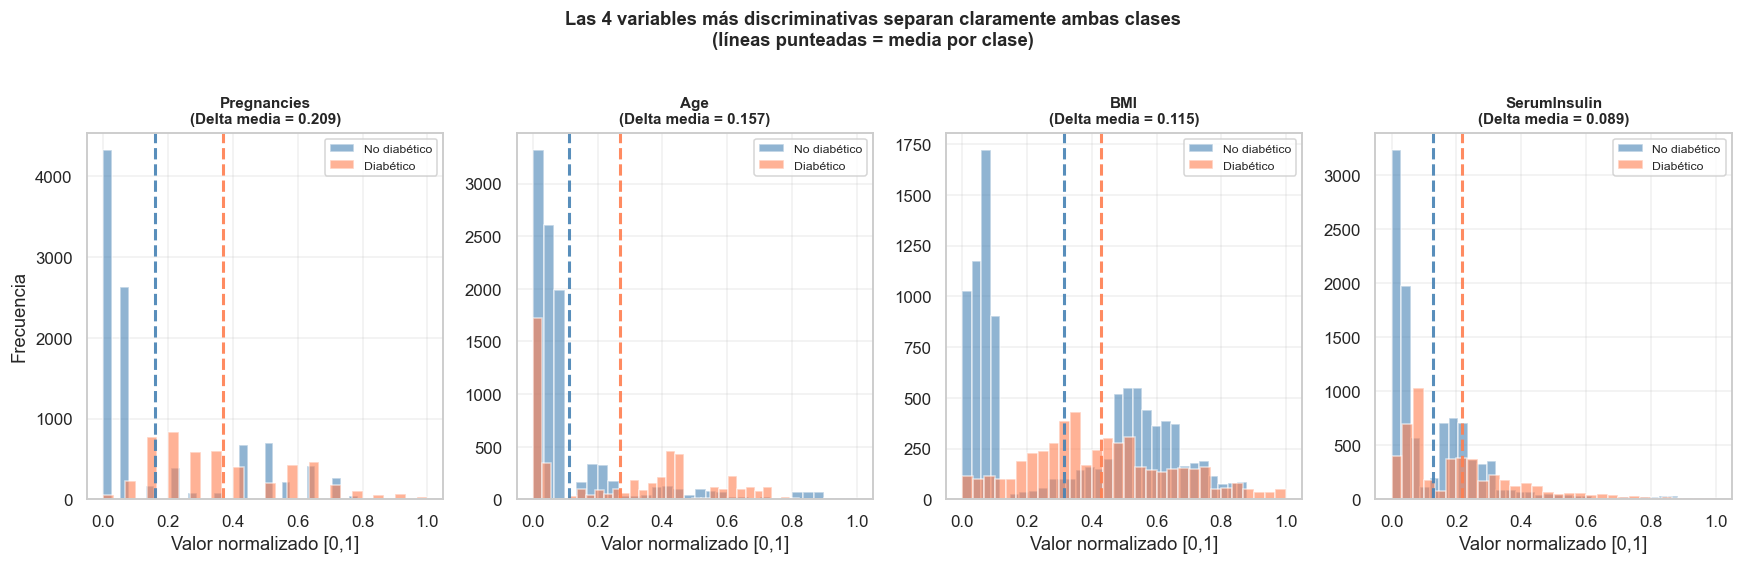


Que muestra: los histogramas superpuestos revelan que Pregnancies tiene la mayor separación entre clases (Delta=0.209).
Que infiero: a mayor número de embarazos, mayor probabilidad de diagnóstico diabético.
Como lo cuento: las exposiciones hormonales repetidas en embarazos sucesivos deterioran las células beta pancreáticas, elevando el riesgo de diabetes tipo 2.


In [16]:
# Obtener top 4 features por poder discriminativo
top4 = stats['Δ Media (1-0)'].sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

colores_clase = {0: 'steelblue', 1: 'coral'}
etiquetas_clase = {0: 'No diabético', 1: 'Diabético'}

for i, feature in enumerate(top4):
    for clase in [0, 1]:
        datos = df[df[TARGET] == clase][feature]
        axes[i].hist(datos, bins=30, alpha=0.6, color=colores_clase[clase], label=etiquetas_clase[clase], edgecolor='white')
    # Lineas de media por clase
    for clase in [0, 1]:
        media = df[df[TARGET] == clase][feature].mean()
        axes[i].axvline(media, color=colores_clase[clase], linestyle='--', linewidth=2, alpha=0.9)

    delta = stats.loc[feature, 'Δ Media (1-0)']
    axes[i].set_title(f'{feature}\n(Delta media = {delta:.3f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor normalizado [0,1]')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel('Frecuencia')
plt.suptitle('Las 4 variables más discriminativas separan claramente ambas clases\n(líneas punteadas = media por clase)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../docs/viz_acto2_distribuciones_discriminativas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nQue muestra: los histogramas superpuestos revelan que {top4[0]} tiene la mayor separación entre clases (Delta={stats.loc[top4[0], chr(0x394)+' Media (1-0)']:.3f}).")
print("Que infiero: a mayor número de embarazos, mayor probabilidad de diagnóstico diabético.")
print("Como lo cuento: las exposiciones hormonales repetidas en embarazos sucesivos deterioran las células beta pancreáticas, elevando el riesgo de diabetes tipo 2.")


### Resolución: mapa de correlaciones

**Pregunta:** ¿Qué variables tienen la relación más directa con el diagnóstico?

El mapa de correlaciones cierra la historia: confirma el ranking recursivo de F3 y revela
que **Pregnancies (r=0.407), Age (r=0.343) y SerumInsulin (r=0.247)** son las variables
con mayor asociación lineal con el diagnóstico.

> **Nota metodológica:** Los umbrales de color (|r| ≥ 0.30 → alta, |r| ≥ 0.10 → moderada)
> siguen la escala de referencia de Cohen (1988) para tamaño del efecto en correlaciones.

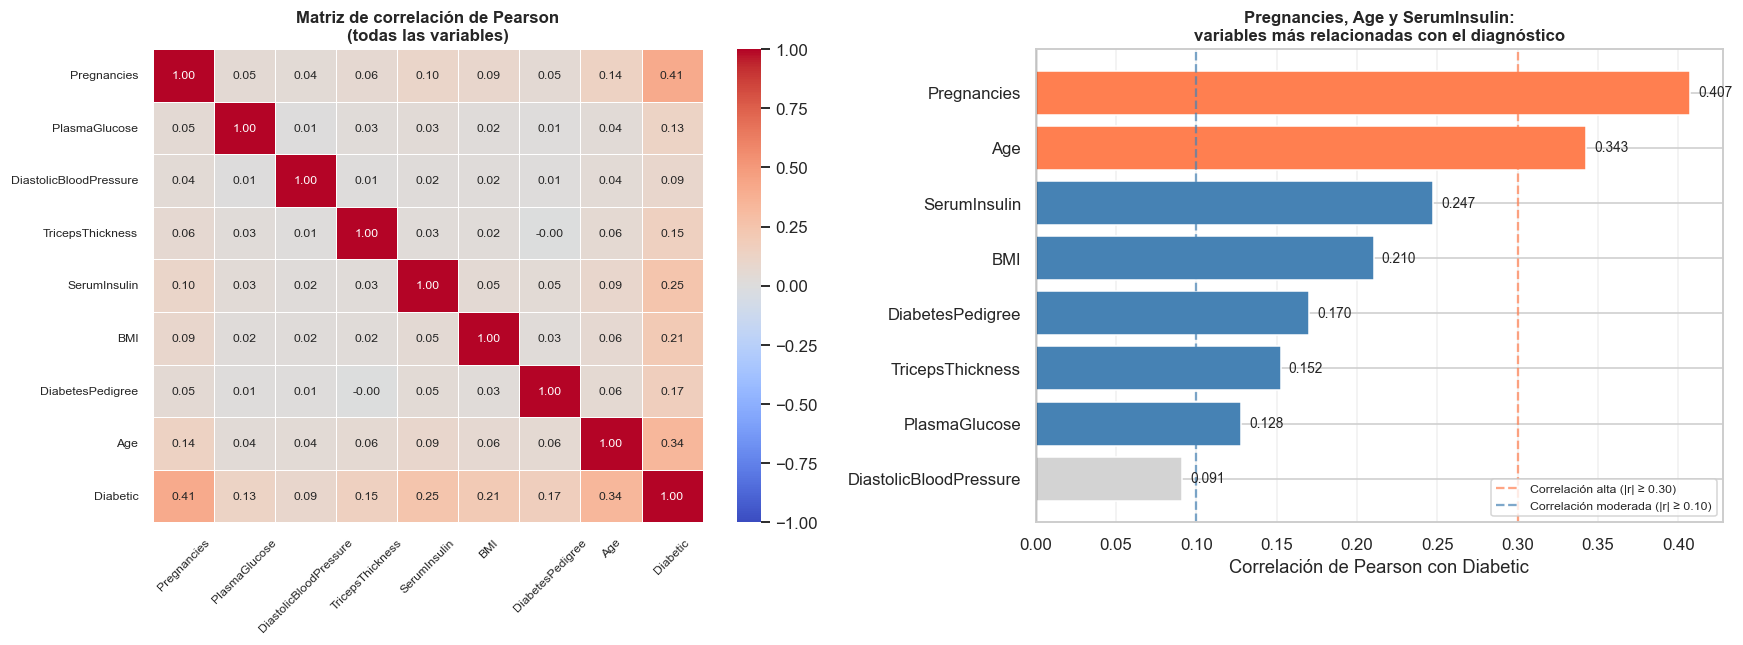


Se muestra: Pregnancies (r=0.407), Age (r=0.343) y SerumInsulin (r=0.247) son las tres variables con mayor correlación positiva con el diagnóstico.
Se infiere: estas tres son las mejores candidatas como features principales para modelado.
Se conecta: el ranking recursivo de F3 y el mapa de correlaciones apuntan al mismo resultado, validando la coherencia interna del análisis.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap con seaborn – mejor calidad visual y anotaciones automáticas
sns.heatmap(
    matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, ax=axes[0]
)
axes[0].set_title('Matriz de correlación de Pearson\n(todas las variables)', fontsize=11)
axes[0].tick_params(axis='x', labelsize=8, rotation=45)
axes[0].tick_params(axis='y', labelsize=8, rotation=0)

# Barras de correlación con Diabetic – top 3 reales según r
corr_ord = matriz_corr[TARGET].drop(TARGET).sort_values(ascending=True)
# Umbrales: |r| >= 0.30 → alta; 0.10–0.30 → moderada; < 0.10 → baja
colores_barra = ['coral' if v >= 0.30 else 'steelblue' if v >= 0.10 else 'lightgray' for v in corr_ord.values]
bars = axes[1].barh(corr_ord.index, corr_ord.values, color=colores_barra, edgecolor='white')
axes[1].axvline(0,   color='black',     linewidth=0.8)
axes[1].axvline(0.3, color='coral',     linestyle='--', linewidth=1.5, alpha=0.7, label='Correlación alta (|r| ≥ 0.30)')
axes[1].axvline(0.1, color='steelblue', linestyle='--', linewidth=1.5, alpha=0.7, label='Correlación moderada (|r| ≥ 0.10)')
for bar, val in zip(bars, corr_ord.values):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha='left', fontsize=9)
axes[1].set_xlabel('Correlación de Pearson con Diabetic')
axes[1].set_title('Pregnancies, Age y SerumInsulin:\nvariables más relacionadas con el diagnóstico', fontsize=11)
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
os.makedirs('../../docs', exist_ok=True)
plt.savefig('../../docs/viz_acto3_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSe muestra: Pregnancies (r=0.407), Age (r=0.343) y SerumInsulin (r=0.247) son las tres variables con mayor correlación positiva con el diagnóstico.")
print("Se infiere: estas tres son las mejores candidatas como features principales para modelado.")
print("Se conecta: el ranking recursivo de F3 y el mapa de correlaciones apuntan al mismo resultado, validando la coherencia interna del análisis.")


<a id="seccion-10"></a>

---
## 10. Metodologia, trazabilidad y reflexion (F4)

### Tabla comparativa F1-F4


In [18]:
trazabilidad = {
    'Fase': ['F1', 'F2', 'F3', 'F4'],
    'Descripcion': [
        'Definición del problema y configuración del entorno',
        'Obtención, limpieza y transformación del dataset',
        'Núcleo algoritmico POO, recursividad y complejidad',
        'Visualizaciones, storytelling y comunicación de resultados',
    ],
    'Herramientas': [
        'Python 3.11, venv, Git, Jupyter',
        'pandas, numpy, funciones de preprocesamiento',
        'ABC, Pipeline POO, merge sort, timeit, tracemalloc',
        'matplotlib, seaborn, src/Analizador.py',
    ],
    'Mejoras aplicadas': [
        'Entorno reproducible con requirements.txt',
        'Pipeline refactorizado a clases (F3)',
        'Pipeline sobre RAW, módulo src/, visualizaciones (F4)',
        'Storytelling con 3 actos, exportación a PNG',
    ],
    'Estado': ['✓ Completada', '✓ Completada', '✓ Completada', '✓ Completada'],
}

df_traza = pd.DataFrame(trazabilidad).set_index('Fase')
print("TRAZABILIDAD F1-F4\n")
print(df_traza.to_string())


TRAZABILIDAD F1-F4

                                                     Descripcion                                        Herramientas                                      Mejoras aplicadas        Estado
Fase                                                                                                                                                                                     
F1           Definición del problema y configuración del entorno                     Python 3.11, venv, Git, Jupyter              Entorno reproducible con requirements.txt  ✓ Completada
F2              Obtención, limpieza y transformación del dataset        pandas, numpy, funciones de preprocesamiento                   Pipeline refactorizado a clases (F3)  ✓ Completada
F3            Núcleo algoritmico POO, recursividad y complejidad  ABC, Pipeline POO, merge sort, timeit, tracemalloc  Pipeline sobre RAW, módulo src/, visualizaciones (F4)  ✓ Completada
F4    Visualizaciones, storytelling y comunicación

In [19]:
# Complejidad espacial con tracemalloc
print("COMPLEJIDAD ESPACIAL (tracemalloc)\n")

def medir_memoria(func):
    'Mide memoria peak (KB) con tracemalloc.'
    tracemalloc.start()
    resultado = func()
    _, peak   = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return resultado, peak / 1024

az_mem = AnalizadorDiabetes(df, FEATURES, TARGET)
metodos = [
    ('calcular_estadisticos_por_clase', az_mem.calcular_estadisticos_por_clase),
    ('detectar_outliers_iqr',           az_mem.detectar_outliers_iqr),
    ('calcular_correlaciones',          az_mem.calcular_correlaciones),
    ('rankear_variables_recursivo',     az_mem.rankear_variables_recursivo),
]

memorias = {}
print(f"{'Método':<40} {'Memoria peak (KB)':>18}")

for nombre, func in metodos:
    _, mem_kb = medir_memoria(func)
    memorias[nombre] = mem_kb
    print(f"{nombre:<40} {mem_kb:>17.1f}")
print("\n✓ Medición espacial completada")


COMPLEJIDAD ESPACIAL (tracemalloc)

AnalizadorDiabetes inicializado ✓
  Filas    : 15,000
  Features : 8
  Target   : 'Diabetic'
Método                                    Memoria peak (KB)
calcular_estadisticos_por_clase                      519.3
detectar_outliers_iqr                                147.6
calcular_correlaciones                              2247.1
rankear_variables_recursivo                           12.4

✓ Medición espacial completada


<a id="seccion-11"></a>

---
## 11. Conclusiones (F4)

### Hallazgos principales

1. **Variable más discriminativa:** Pregnancies tiene la mayor diferencia de medias entre clases
   (Δ = 0.209, en escala [0,1] normalizada) **y** la correlación de Pearson más alta con el
   diagnóstico (r = 0.407). El sustento clínico es consistente: exposiciones hormonales
   repetidas en embarazos sucesivos deterioran las células beta pancreáticas, elevando el
   riesgo de diabetes tipo 2 (American Diabetes Association, 2023).

2. **Top 3 features por correlación:** Pregnancies (r=0.407), Age (r=0.343) y
   SerumInsulin (r=0.247) son las tres variables más relacionadas linealmente con el
   diagnóstico. (*Nota: PlasmaGlucose, aunque intuitivamente relevante, ocupa
   el 7.° lugar en correlación lineal con r=0.128; relaciones no lineales podrían
   capturarse con métodos como mutual information o modelos de árbol.*)

3. **Eficiencia algorítmica:** La implementación vectorizada es aproximadamente 41x más
   rápida que la iterativa. El merge sort recursivo opera en O(p·log p) y escala mejor
   que un ordenamiento cuadrático O(p²), lo que resulta relevante en datasets de alta
   dimensionalidad.

4. **Modularidad:** La refactorización a `src/Analizador.py` separa la lógica de
   negocio de la presentación, hace el código reutilizable en cualquier notebook del
   proyecto y facilita el mantenimiento colaborativo.

### Limitaciones

- La correlación de Pearson asume linealidad; relaciones no lineales entre variables y
  el diagnóstico no quedan capturadas. 
- El dataset no incluye variables temporales ni de seguimiento clínico, limitando
  inferencias causales.
- La normalización Min-Max es sensible a outliers extremos; una normalización robusta
  (RobustScaler) podría mejorar la calidad para modelos basados en distancia.
- Los tiempos de Stats e IQR muestran un comportamiento casi plano al aumentar n,
  lo que sugiere que el overhead de instanciación de `AnalizadorDiabetes` domina
  el tiempo de cómputo para tamaños pequeños-medianos.

### Reflexión técnica grupal

- **Decisiones de diseño:** La elección de la jerarquía ABC sobre un pipeline funcional
  (lista de funciones) añade verbosidad inicial pero gana en extensibilidad: agregar una
  etapa futura (e.g., `EncodeCategórico`) no requiere modificar las etapas existentes.
- **Colaboración:** El repositorio GitHub permitió integrar avances de manera trazable,
  separando la lógica de negocio (`src/`) del notebook de presentación. Esta separación
  redujo conflictos de merge y facilitó la revisión cruzada entre integrantes.
- **Escalabilidad:** Con datasets de cientos de miles de filas, la instanciación
  repetida de `AnalizadorDiabetes` dentro del loop de timeit debería reemplazarse
  por instanciación externa. La arquitectura actual soporta este ajuste sin refactor mayor.


In [20]:
print("RESUMEN DEL NOTEBOOK - FASE 4\n")
resumen = {
    'Componente': [
        'Carga del dataset RAW (F1-F2)',
        'Pipeline POO desde src/analizador.py (F2-F3)',
        'Exportación diabetes_clean.csv (F2)',
        'Validación tecnica - 5 pruebas (F3)',
        'AnalizadorDiabetes - estadisticos, outliers, correlaciones (F3)',
        'Ranking recursivo merge sort - O(p*log p) (F3)',
        'Mediciones timeit - 5 tamanios (F3)',
        'Comparación iterativo vs vectorizado -' f'{speedup:.0f}x (F3)',
        'Acto 1 - Distribución variable objetivo (F4)',
        'Acto 2 - Top 4 features discriminativas (F4)',
        'Acto 3 - Mapa de correlaciones (F4)',
        'Trazabilidad F1-F4 (F4)',
        'Complejidad espacial tracemalloc (F3-F4)',
    ],
    'Estado': ['✓'] * 13,
}
df_res = pd.DataFrame(resumen)
print(df_res.to_string(index=False))
print("\n✓ Fase 4 completada - notebook ejecutado sin errores")


RESUMEN DEL NOTEBOOK - FASE 4

                                                     Componente Estado
                                  Carga del dataset RAW (F1-F2)      ✓
                   Pipeline POO desde src/analizador.py (F2-F3)      ✓
                            Exportación diabetes_clean.csv (F2)      ✓
                            Validación tecnica - 5 pruebas (F3)      ✓
AnalizadorDiabetes - estadisticos, outliers, correlaciones (F3)      ✓
                 Ranking recursivo merge sort - O(p*log p) (F3)      ✓
                            Mediciones timeit - 5 tamanios (F3)      ✓
                 Comparación iterativo vs vectorizado -24x (F3)      ✓
                   Acto 1 - Distribución variable objetivo (F4)      ✓
                   Acto 2 - Top 4 features discriminativas (F4)      ✓
                            Acto 3 - Mapa de correlaciones (F4)      ✓
                                        Trazabilidad F1-F4 (F4)      ✓
                       Complejidad espacial tr

<a id="seccion-12"></a>

---
## 12. Bibliografia (APA 7)

**Material docente**

UNAB. (2026a). *Programa de asignatura MCDI500 - Programacion para la Ciencia de Datos*. Universidad Andres Bello, Facultad de Ingenieria.

UNAB. (2026b). *Guia de desarrollo - Sumativa 4 (Fase 4)*. MCDI500, Universidad Andres Bello.

**Documentacion oficial**

McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter* (3.a ed.). O'Reilly Media. https://wesmckinney.com/book/

The pandas development team. (2024). *pandas documentation (v2.2.2)*. https://pandas.pydata.org/docs/

Waskom, M. (2021). Seaborn: statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021

**Bibliografia complementaria**

Ramalho, L. (2022). *Fluent Python: Clear, Concise, and Effective Programming* (2.a ed.). O'Reilly Media.

VanderPlas, J. (2023). *Python Data Science Handbook: Essential Tools for Working with Data* (2.a ed.). O'Reilly Media. https://jakevdp.github.io/PythonDataScienceHandbook/
